In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [162]:
from google.colab import files

uploaded = files.upload()

Saving cnn_image_classification_digits.csv to cnn_image_classification_digits (16).csv


In [163]:
df = pd.read_csv("cnn_image_classification_digits.csv")

print("Dataset Loaded Successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset Loaded Successfully!
Dataset Shape: (1797, 65)


,label,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,pixel_64
0,0,0,0,5,13,9,1,0,0,0,...,0,0,0,0,6,13,10,0,0,0
1,1,0,0,0,12,13,5,0,0,0,...,0,0,0,0,0,11,16,10,0,0
2,2,0,0,0,4,15,12,0,0,0,...,5,0,0,0,0,3,11,16,9,0
3,3,0,0,7,15,13,1,0,0,0,...,9,0,0,0,7,13,13,9,0,0
4,4,0,0,0,1,11,0,0,0,0,...,0,0,0,0,0,2,16,4,0,0


In [164]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   label     1797 non-null   int64
 1   pixel_1   1797 non-null   int64
 2   pixel_2   1797 non-null   int64
 3   pixel_3   1797 non-null   int64
 4   pixel_4   1797 non-null   int64
 5   pixel_5   1797 non-null   int64
 6   pixel_6   1797 non-null   int64
 7   pixel_7   1797 non-null   int64
 8   pixel_8   1797 non-null   int64
 9   pixel_9   1797 non-null   int64
 10  pixel_10  1797 non-null   int64
 11  pixel_11  1797 non-null   int64
 12  pixel_12  1797 non-null   int64
 13  pixel_13  1797 non-null   int64
 14  pixel_14  1797 non-null   int64
 15  pixel_15  1797 non-null   int64
 16  pixel_16  1797 non-null   int64
 17  pixel_17  1797 non-null   int64
 18  pixel_18  1797 non-null   int64
 19  pixel_19  1797 non-null   int64
 20  pixel_20  1797 non-null   int64
 21  pixel_21  1797 non-null   int64
 22  

In [165]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
label       0
pixel_1     0
pixel_2     0
pixel_3     0
pixel_4     0
           ..
pixel_60    0
pixel_61    0
pixel_62    0
pixel_63    0
pixel_64    0
Length: 65, dtype: int64


In [166]:
X = df.drop("label", axis=1)
y = df["label"]

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (1797, 64)
Label Shape: (1797,)


In [167]:
X = X.values.astype("float32")

# Normalize pixel values
X = X / 16.0

print("Normalization Completed!")

Normalization Completed!


In [168]:
X = X.reshape(-1, 8, 8, 1)

print("Reshaped Data Shape:", X.shape)

Reshaped Data Shape: (1797, 8, 8, 1)


In [169]:
y = to_categorical(y, num_classes=10)

print("Categorical Label Shape:", y.shape)

Categorical Label Shape: (1797, 10)


In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1437, 8, 8, 1)
Testing Data Shape: (360, 8, 8, 1)


In [171]:
model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(8, 8, 1)
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 6, 6, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 1, 1, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,426 (111.04 KB)

 Trainable params: 28,426 (111.04 KB)

 Non-trainable params: 0 (0.00 B)

In [172]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [173]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2620 - loss: 2.2048 - val_accuracy: 0.6771 - val_loss: 2.0078
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6501 - loss: 1.5648 - val_accuracy: 0.7674 - val_loss: 1.0562
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7850 - loss: 0.7844 - val_accuracy: 0.8715 - val_loss: 0.5018
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8660 - loss: 0.4813 - val_accuracy: 0.9028 - val_loss: 0.3717
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9164 - loss: 0.3246 - val_accuracy: 0.9167 - val_loss: 0.2655
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9095 - loss: 0.2994 - val_accuracy: 0.9306 - val_loss: 0.2421
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9373 - loss: 0.2389 - val_accuracy: 0.9444 - val_loss: 0.1861
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9487 - loss: 0.1946 - val_accuracy: 0.9410 - val_loss

In [174]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.07073045521974564
Test Accuracy: 0.9666666388511658


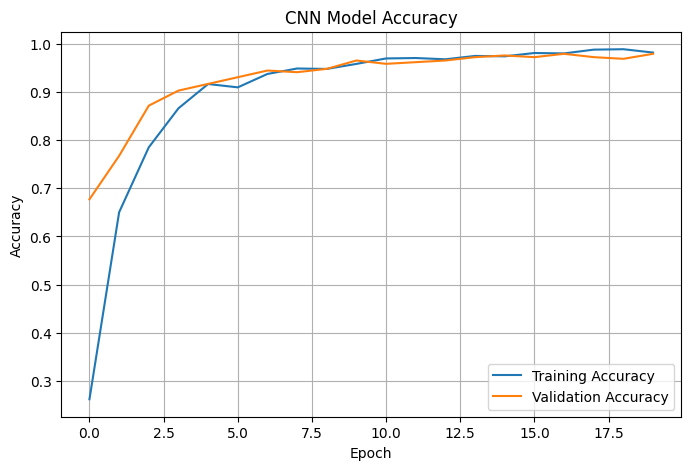

In [175]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

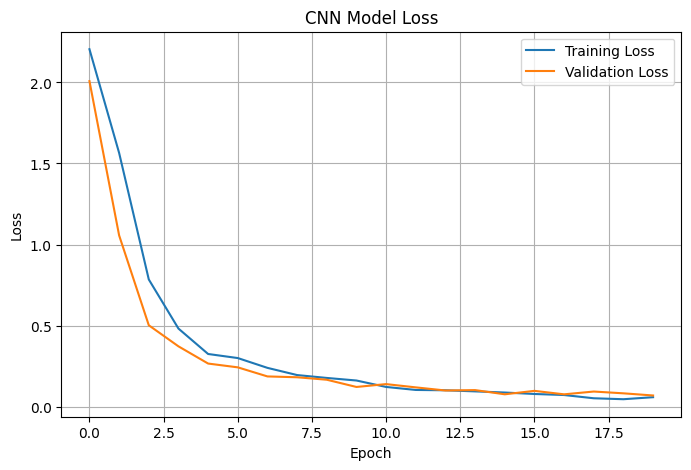

In [176]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [177]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
actual_labels = np.argmax(y_test, axis=1)

print("Predicted Labels:")
print(predicted_labels[:10])

print("\nActual Labels:")
print(actual_labels[:10])

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predicted Labels:
[5 2 8 1 7 2 6 2 6 5]

Actual Labels:
[5 2 8 1 7 2 6 2 6 5]


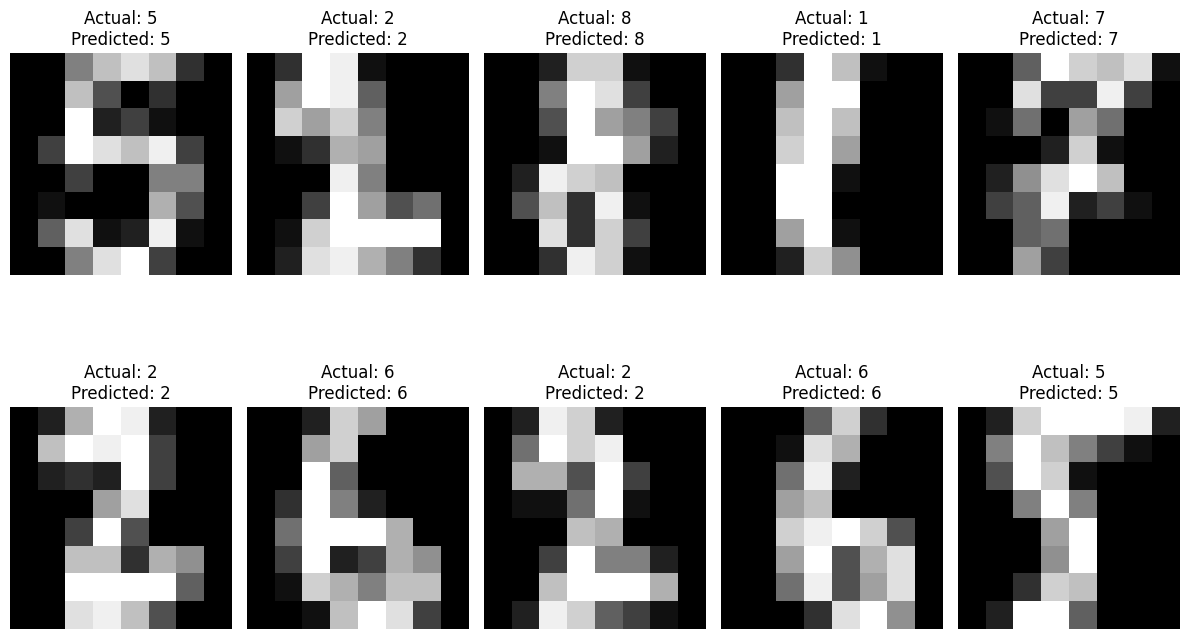

In [178]:
plt.figure(figsize=(12, 8))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i].reshape(8, 8), cmap="gray")

    plt.title(
        f"Actual: {actual_labels[i]}\nPredicted: {predicted_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [179]:
model.save("cnn_image_classification_model.keras")

print("CNN Model Saved Successfully!")

CNN Model Saved Successfully!


In [180]:
from google.colab import files

files.download("cnn_image_classification_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>